# <font color='056938'> **Load modules** </font>

We will load into this notebook some modules with functions that will help you in the development of heuristics and metaheuristics for the solution of travelling salesman problemas

The module `random_generators.py` include the functions to deal with generating random numbers. It is based on the code of Taillard (2023) that in turn is based on L'Ecuyer random number generator.The ultimate function of this module is to generate a random permutation (solution) of the tsp problem
* Random tour generation: `rand_permutation`

The module `tsp_tools` provides different functions to help from the data reading to the solution ploting
* Data reading: `read_data(filepath)`
> `filepath`: the route to the file with the instance's data
* Distance calculation: `calculate_distances`
* Data display: `print_TSPdata()
* Solution evaluation: `tsp_distance`
* Tour display: `plot_tsp_route()`
* Plot the search trayectory `plot_trace(trace)`

In [1]:
import random_generators as ran_gen
import tsp_tools as TSPtools
import pandas as pd

## <font color='8EC044'> **Test instances** </font>

We will use a clasical test instances with the structure described in  [TSPlib](http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/). Particularly we are using two instances

* `berlin52.tsp`: It consideres 52 cities
* `prueba10.tsp`: A small instance with 10 cities



First we load the datafile to the colab environment

We load the data using the `function read_data()` from the module `TSPtools`. The data we load is the list of coordinates for each of the cities

In [2]:
data = TSPtools.read_data("prueba10.tsp")             #Read the data
data

[[565.0, 575.0],
 [25.0, 185.0],
 [345.0, 750.0],
 [945.0, 685.0],
 [845.0, 655.0],
 [880.0, 660.0],
 [25.0, 230.0],
 [525.0, 1000.0],
 [580.0, 1175.0],
 [650.0, 1130.0]]

We visualize the data in a scatter plot

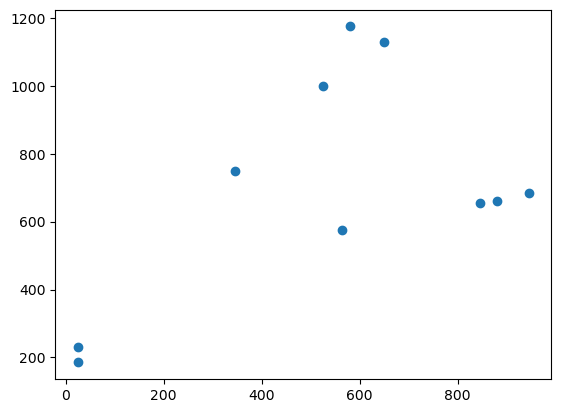

In [3]:
TSPtools.print_TSPdata(data)

Finally, we can compute the distance matrix

In [4]:
distances=TSPtools.calculate_distances(data)
distances

array([[   0.        ,  666.10809934,  281.11385594,  395.6008089 ,
         291.20439557,  326.26676202,  640.8002809 ,  426.87820277,
         600.18747071,  561.47128155],
       [ 666.10809934,    0.        ,  649.32657423, 1047.09120902,
         945.14549145,  978.08486339,   45.        ,  956.15113868,
        1134.95594628, 1132.98278892],
       [ 281.11385594,  649.32657423,    0.        ,  603.51056329,
         508.9449872 ,  542.51728083,  610.5735009 ,  308.05843601,
         485.64390246,  487.26276279],
       [ 395.6008089 , 1047.09120902,  603.51056329,    0.        ,
         104.40306509,   69.64194139, 1026.36494484,  525.        ,
         611.00327331,  533.90073984],
       [ 291.20439557,  945.14549145,  508.9449872 ,  104.40306509,
           0.        ,   35.35533906,  923.59352531,  470.55817919,
         583.6308765 ,  513.4685969 ],
       [ 326.26676202,  978.08486339,  542.51728083,   69.64194139,
          35.35533906,    0.        ,  957.0397066 ,  491

## **Components of metaheuristics**##


 With a few components we can code different metaheuristics:
 + A constructive heuristic for initial solutiona
 + Some neighborhood operators
 + A perturbation operator

 Lets see some examples of these components and then use them to have a local search based metaheuristics

### <font color='46B8A9'> **Nearest neighbor construction for the TSP** </font>



In [5]:
######### Nearest Neighbour greedy heuristic for the TSP
def tsp_nearest_neighbour(d, tour): # Distance matrix  and list of cities to visit
  n = len(tour)
  length = 0 # Tour length
  for i in range(1, n): # Cities from tour[0] to tour[i-1] are fixed
    nearest = i # Next nearest city to insert
    cost_ins = d[tour[i-1]][tour[i]] # City insertion cost
    for j in range(i+1, n): # Find next city to insert
      if d[tour[i-1]][tour[j]] < cost_ins:
        cost_ins = d[tour[i-1]][tour[j]]
        nearest = j
    length += cost_ins
    tour[i], tour[nearest] = tour[nearest], tour[i] # Definitive insertion
  length += d[tour[n - 1]][tour[0]] # Come back to start
  return tour, length

**Test the NNH**

In [6]:
tour=[0,1,2,3,4,5,6,7,8,9]

sol, distance = tsp_nearest_neighbour(distances, tour)
sol

[0, 2, 7, 9, 8, 4, 5, 3, 6, 1]

### <font color='46B8A9'> **Neighborhoods** </font>



**2-Opt**

A 2-opt move works by selecting two non-adjacent edges in the tour, removing them, and reconnecting the resulting segments in the opposite order. This reversal of a tour segment often results in a shorter total distance.

The operation works as follows:

1. **Select Two Edges**:
   - Choose two edges (i.e., two pairs of consecutive cities in the tour) that are not adjacent to each other. These edges connect four cities in the current tour.

2. **Remove the Two Edges**:
   - Remove the selected edges, which splits the tour into two segments.

3. **Reverse the Segment**:
   - Reverse the order of the cities in one of the segments. This effectively changes the way the two segments are connected.

4. **Reconnect the Segments**:
   - Reconnect the segments by joining the first city of the reversed segment to the last city of the first segment and the last city of the reversed segment to the first city of the second segment.


This figure shows an example the movement

![2opt](https://docs.google.com/uc?export=download&id=1LFh5xwC269JosE4VTnZGRvPvzGYArD67)



Based on the code proposed in Taillard (2023), this is the code of a function that performs the 2-opt operation.

In [7]:
import copy

def two_opt_swap(tour, i, j):
    new_tour = copy.deepcopy(tour)
    while i < j:
      new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
      i, j = i + 1, j- 1

    return new_tour

Let's see how this move can be used to create a neighbor to a current solution.

In [8]:
print(sol)
sol2=two_opt_swap(sol,1,4)
sol2

[0, 2, 7, 9, 8, 4, 5, 3, 6, 1]


[0, 8, 9, 7, 2, 4, 5, 3, 6, 1]

**Swap**

In [9]:
def swap(tour,i,j):
  """
  Swaps the positions of two randomly selected cities in a TSP tour.

  Args:
    tour: A list representing a TSP tour (permutation of city indices).

  Returns:
    A new list representing the modified tour with two cities swapped.
  """
  # Create a copy to avoid modifying the original tour
  new_tour = tour[:]

    # Swap the elements at the selected indices
  new_tour[i], new_tour[j] = new_tour[j], new_tour[i]

  return new_tour

In [10]:
print(sol)
sol3=swap(sol,1,4)
sol3

[0, 2, 7, 9, 8, 4, 5, 3, 6, 1]


[0, 8, 7, 9, 2, 4, 5, 3, 6, 1]

**Insert**

In [11]:
def insert(tour,i,j):
  """
  Selects a random position in a TSP tour and reinserts it into another random position.

  Args:
    tour: A list representing a TSP tour (permutation of city indices).

  Returns:
    A new list representing the modified tour with the element moved.
  """
  # Create a copy to avoid modifying the original tour
  new_tour = tour[:]

  # Select a random index to remove
  removed_idx = i

  # Remove the element at the selected index
  removed_element = new_tour.pop(removed_idx)

  # Select a new random index to insert
  inserted_idx = j

  # Insert the removed element at the new index
  new_tour.insert(inserted_idx, removed_element)

  return new_tour


In [12]:
print(sol)
sol4=insert(sol,1,4)
sol4

[0, 2, 7, 9, 8, 4, 5, 3, 6, 1]


[0, 7, 9, 8, 2, 4, 5, 3, 6, 1]

##A perturbation operator (double bridge)



As sugested in (Lourenço H.R., et al., 2001) we will consider the double bridge move. That involves selecting four distinct points in the tour and rearranging the segments between these points in a specific way to explore new solutions, effectively creating a new permutation by swapping two segments of the tour with each other.

![Bridge](https://docs.google.com/uc?export=download&id=15epME5cqtKL8omf-DFC_gWzTVFfMNOe6)

The following function apply the double bridge move to a given solution




In [13]:
import numpy as np

def double_bridge_move(tour):

    n = len(tour)
    if n < 8:
        raise ValueError("Tour must have at least 8 cities to apply Double Bridge Move.")

    # Randomly select four distinct points in the tour
    indices = np.random.choice(range(1,n), 4, replace=False)
    indices.sort()

    i1, i2, i3, i4 = indices

    # Extract segments
    segment1 = tour[i1:i2 + 1]
    segment2 = tour[i2 + 1:i3 + 1]
    segment3 = tour[i3 + 1:i4 + 1]
    segment4 = np.concatenate([tour[i4 + 1:], tour[:i1]]) if i4 < n - 1 else tour[:i1]

    # Rearrange segments to form the new tour
    new_tour = np.concatenate([segment1, segment3, segment2, segment4])

    # Adjust the new tour to maintain the original length
    new_tour = new_tour[:n]

    return new_tour.tolist()




In [14]:
print(sol)
sol5=double_bridge_move(sol)
sol5

[0, 2, 7, 9, 8, 4, 5, 3, 6, 1]


[7, 9, 5, 3, 6, 8, 4, 1, 0, 2]

## <font color='8EC044'> **A SIMPLE LOCAL SEARCH**  </font>

The search enumerates solutions in the neighboorhoud. This enumeration can be done according to two policies, either the ***first improvement*** or the ***best improvement***.

#### <font color='46B8A9'> **Example** </font>

To solve the TSP through a local serach you already have the following components
* A routine to create a initial solution (use the random initial in this case)
* A routine to find a neighbour of the current solution with `2-opt`
* A routine to evaluate a given solution

We ese these elements to build a **Local search with first improvement**

In [15]:
# Write your code here

import numpy as np
import pandas as pd
np.random.seed(42)

# Defines a function that performs the search

def localSearch_FirstImprov(solution, distances):

  data=[]

  solution_val = TSPtools.tsp_distance(distances, solution)
  # flag to activate the iteration
  improvement = True

  while improvement:
    break_forloop = False # flag to break two loops when finding a better solution
    improvement = False
    for i in range(n-2):
        for j in range (i+2, n-1):
          neighbour = two_opt_swap(solution, i, j)
          neigbour_val = TSPtools.tsp_distance(distances, neighbour)
          # Save all explored solutions
          data.append([len(data)+1, neigbour_val])
          if neigbour_val < solution_val:
            solution_val = neigbour_val
            solution = neighbour
            improvement = True
            break_forloop = True
            #print(f'value: {incumbent_val:1f}')
            data[-1].append("Improve")
            break
        if break_forloop:
          break

  df = pd.DataFrame(data, columns=['iter', 'value', 'improve'])
  df_improve = df[df['improve']=='Improve']
  best_sol = df_improve.iloc[-1]['value']

  return  best_sol, df





We now apply the function to a random solution

In [ ]:
# read data
data = TSPtools.read_data("berlin52.tsp")
distances=TSPtools.calculate_distances(data)
n = len(distances)

# Generate a random permutation
solution = np.random.permutation(n)
print(TSPtools.tsp_distance(distances, solution))
best_sol, df = localSearch_FirstImprov(solution, distances)
print(f'The best solution value is {best_sol}')

30300.763603354186


In [ ]:
df

We graph the value of the objective for the different iterations

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Create the first scatter plot
all_neigh = go.Scatter(
    x=df['iter'],
    y=df['value'],
    mode='lines+markers',
    marker=dict(color='blue'),
    name='Neighbours'
)

# Create the second scatter plot
df_improve = df[df['improve']=='Improve']
improve = go.Scatter(
    x=df_improve['iter'],
    y=df_improve['value'],
    mode='lines+markers',
    marker=dict(color='red'),
    name='Improvements'
)

fig.add_trace(all_neigh)
fig.add_trace(improve)

fig.update_traces(marker_size=4, opacity=0.7)
fig.update_layout(
          xaxis_title="Iteración",
          yaxis_title="diatancia",
      )


fig

#### <font color=red> **Exercise** </font>

 **Use the functions given above to create one of the following methods**
 + A GRASP
 + An ILS
 + A VNS

 #### <font color=blue> **But the method that you have to code is randomly selected draw a small paper** </font>


# <font color='056938'> **References** </font>


* Taillard, É. D. (2023). Design of heuristic algorithms for hard optimization: with python codes for the travelling salesman problem. Springer Nature travelling salesman problem (p. 287). Springer Nature.
* Lourenço, H. R., Martin, O., &amp; Stützle, T. (2001, July). A beginner’s introduction to iterated local search. In&nbsp;Proceedings of MIC&nbsp;(Vol. 2, pp. 1-6).
